In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

In [2]:
import pandas as pd

In [15]:
df = pd.read_csv('Life-Expectancy-Data-Updated (1).csv')

In [32]:
df.columns

Index(['Country', 'Region', 'Year', 'Infant_deaths', 'Under_five_deaths',
       'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles',
       'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita',
       'Population_mln', 'Thinness_ten_nineteen_years',
       'Thinness_five_nine_years', 'Schooling', 'Life_expectancy',
       'Developed'],
      dtype='str')

In [16]:
#creamos la columna binaria correcta
df['Developed'] = (df['Economy_status_Developed'] == 1).astype(int)
df = df.drop(columns=['Economy_status_Developed'])
df = df.drop(columns=['Economy_status_Developing'])

In [18]:
df['Region'].value_counts()

Region
Africa     816
Europe     672
Asia       656
America    544
Oceania    176
Name: count, dtype: int64

In [17]:
df['Region'] = df['Region'].replace(
    to_replace=r'.*Europe.*',
    value='Europe',
    regex=True
)

df['Region'] = df['Region'].replace(
    to_replace=r'.*America.*',
    value='America',
    regex=True
)

df['Region'] = df['Region'].replace(
    to_replace=r'.*East.*',
    value='Asia',
    regex=True
)

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
america = df[df['Region'] == 'America']
asia = df[df['Region'] == 'Asia']
euro = df[df['Region'] == 'Europe']
africa = df[df['Region'] == 'Africa']
oce = df[df['Region'] == 'Oceania']

# print(len(america) + len(asia) + len(euro) + len(africa) + len(oce))

2864


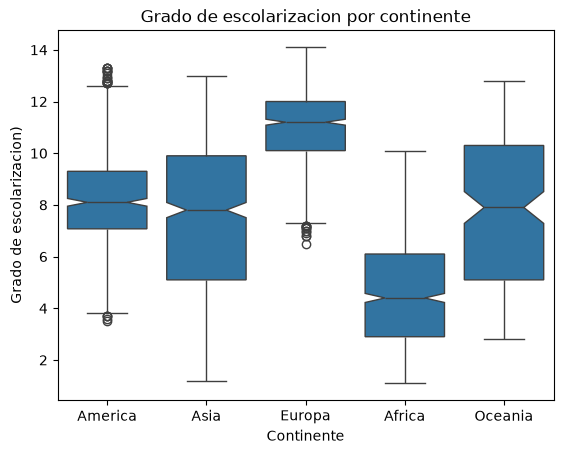

In [36]:
datos_box = pd.concat([
    america[['Schooling']].assign(Categoría='America'),
    asia[['Schooling']].assign(Categoría='Asia'),
    euro[['Schooling']].assign(Categoría='Europa'),
    africa[['Schooling']].assign(Categoría='Africa'),
    oce[['Schooling']].assign(Categoría='Oceania')
])

sns.boxplot(
    x='Categoría',
    y='Schooling',
    data=datos_box,
    notch=True
)

plt.title("Grado de escolarizacion por continente")
plt.xlabel("Continente")
plt.ylabel("Grado de escolarizacion)")

plt.show()

<h3>Normalidad

In [37]:
import scipy.stats as stats

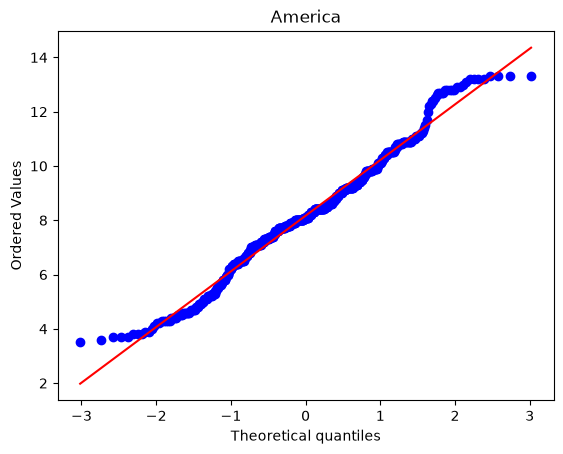

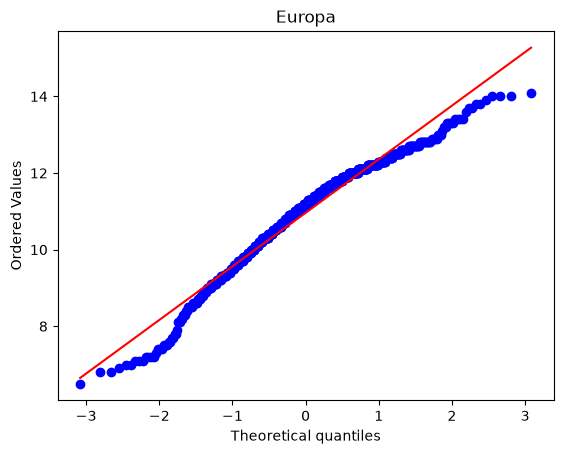

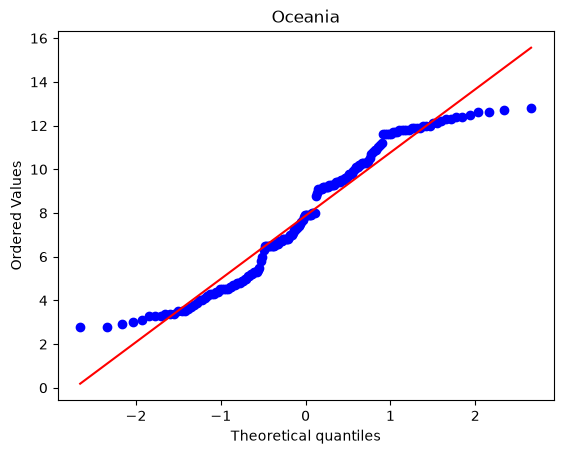

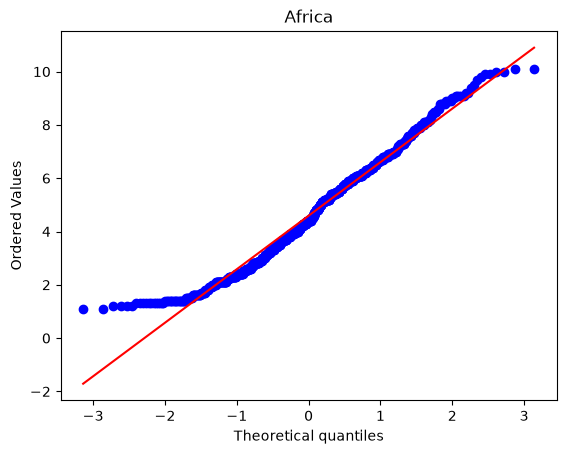

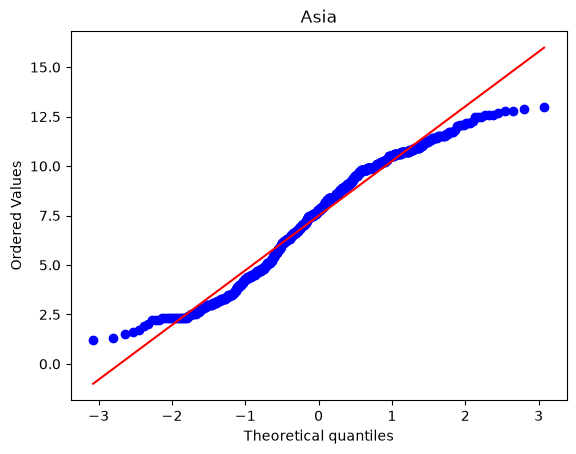

In [ ]:
#QQ plot para paises desarrollados
stats.probplot(america['Schooling'], dist='norm', plot=plt)
plt.title("America")
plt.show()

stats.probplot(euro['Schooling'], dist='norm', plot=plt)
plt.title("Europa")
plt.show()

stats.probplot(oce['Schooling'], dist='norm', plot=plt)
plt.title("Oceania")
plt.show()

stats.probplot(africa['Schooling'], dist='norm', plot=plt)
plt.title("Africa")
plt.show()

stats.probplot(asia['Schooling'], dist='norm', plot=plt)
plt.title("Asia")
plt.show()

In [43]:
from scipy.stats import shapiro

stat, p = shapiro(america['Schooling'])
print(f"Test de Shapiro-Wilk para America: Estadístico={stat:.3f}, p-valor={p:.3f}")

stat, p = shapiro(euro['Schooling'])
print(f"Test de Shapiro-Wilk para Europa: Estadístico={stat:.3f}, p-valor={p:.3f}")

stat, p = shapiro(oce['Schooling'])
print(f"Test de Shapiro-Wilk para Oceania: Estadístico={stat:.3f}, p-valor={p:.3f}")

stat, p = shapiro(asia['Schooling'])
print(f"Test de Shapiro-Wilk para Asia: Estadístico={stat:.3f}, p-valor={p:.3f}")

stat, p = shapiro(africa['Schooling'])
print(f"Test de Shapiro-Wilk para Africa: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para America: Estadístico=0.984, p-valor=0.000
Test de Shapiro-Wilk para Europa: Estadístico=0.967, p-valor=0.000
Test de Shapiro-Wilk para Oceania: Estadístico=0.945, p-valor=0.000
Test de Shapiro-Wilk para Asia: Estadístico=0.967, p-valor=0.000
Test de Shapiro-Wilk para Africa: Estadístico=0.975, p-valor=0.000


<h3>Homocedasticidad

In [45]:
stat, p = stats.levene(america['Schooling'], asia['Schooling'], oce['Schooling'], africa['Schooling'], euro['Schooling'])
print(f"Test de Levene para grado de escolaridad: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para grado de escolaridad: Estadístico=105.095, p-valor=0.000


<h2>Kruskal Wallis

In [47]:
stat, p = stats.kruskal(america['Schooling'], asia['Schooling'], oce['Schooling'], africa['Schooling'], euro['Schooling'])
print(f"Test de Kruskal-Wallis para percentage expenditure: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en el percentage expenditure entre países desarrollados y en vías de desarrollo.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en el grado de escolaridad entre los continentes")

Test de Kruskal-Wallis para percentage expenditure: Estadístico=1532.219, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en el grado de escolaridad entre los continentes


In [51]:
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(
    df,
    val_col='Schooling',
    group_col='Region',
    p_adjust='bonferroni'
)

print(posthoc.round(3))

         Africa  America  Asia  Europe  Oceania
Africa      1.0     0.00  0.00     0.0      0.0
America     0.0     1.00  0.01     0.0      1.0
Asia        0.0     0.01  1.00     0.0      1.0
Europe      0.0     0.00  0.00     1.0      0.0
Oceania     0.0     1.00  1.00     0.0      1.0


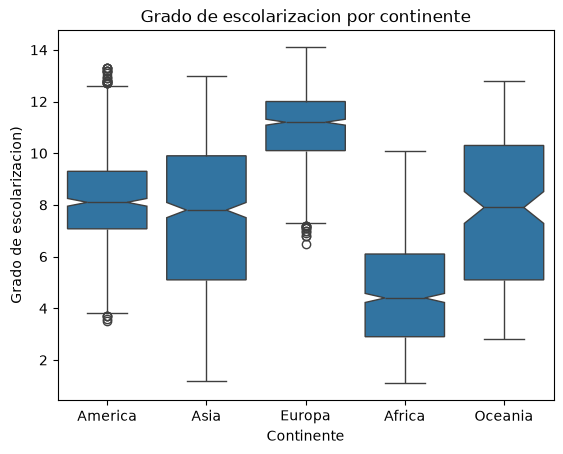